# **1. Perkenalan Dataset**


## Informasi Dataset

**Nama Dataset**: Titanic - Machine Learning from Disaster  
**Sumber**: Kaggle (https://www.kaggle.com/c/titanic/data)  
**Jumlah Sampel**: 891 baris (training set)  
**Jumlah Fitur**: 11 fitur  
**Target**: Survived (0 = Tidak Selamat, 1 = Selamat)  

### Deskripsi Dataset
Dataset Titanic berisi informasi penumpang kapal Titanic yang tenggelam pada April 1912. Tujuan utama adalah memprediksi apakah seorang penumpang selamat atau tidak berdasarkan berbagai fitur seperti kelas tiket, usia, jenis kelamin, dan lainnya.

### Fitur-fitur Dataset:
- `PassengerId`: ID unik penumpang
- `Survived`: Target (0 = Tidak Selamat, 1 = Selamat)
- `Pclass`: Kelas tiket (1, 2, atau 3)
- `Name`: Nama penumpang
- `Sex`: Jenis kelamin
- `Age`: Usia penumpang
- `SibSp`: Jumlah saudara kandung/pasangan di kapal
- `Parch`: Jumlah orang tua/anak di kapal
- `Ticket`: Nomor tiket
- `Fare`: Harga tiket
- `Cabin`: Nomor kabin
- `Embarked`: Port embarkasi (C = Cherbourg, Q = Queenstown, S = Southampton)

# **2. Import Library**

Pada tahap ini, kita mengimpor semua pustaka Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Machine learning models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print('Libraries imported successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.4.6


# **3. Memuat Dataset**

Pada tahap ini, kita memuat dataset ke dalam notebook menggunakan pandas. Dataset diunduh langsung dari URL publik untuk kemudahan reproduksi.

In [3]:
# Load dataset from URL (Titanic dataset - publicly available)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Save raw dataset locally
df.to_csv('titanic_raw.csv', index=False)
print('Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print('\n5 baris pertama dataset:')
df.head()

Dataset berhasil dimuat!
Shape: (891, 12)

5 baris pertama dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Informasi dasar dataset
print('=== Informasi Dataset ===')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print('\nTipe data setiap kolom:')
print(df.dtypes)
print('\nStatistik deskriptif:')
df.describe()

=== Informasi Dataset ===
Jumlah baris: 891
Jumlah kolom: 12

Tipe data setiap kolom:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Statistik deskriptif:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, dilakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset secara mendalam.

In [5]:
# 4.1 Cek Missing Values
print('=== Missing Values Analysis ===')
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
}).sort_values('Missing Percentage', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values Analysis ===
          Missing Count  Missing Percentage
Cabin               687           77.104377
Age                 177           19.865320
Embarked              2            0.224467


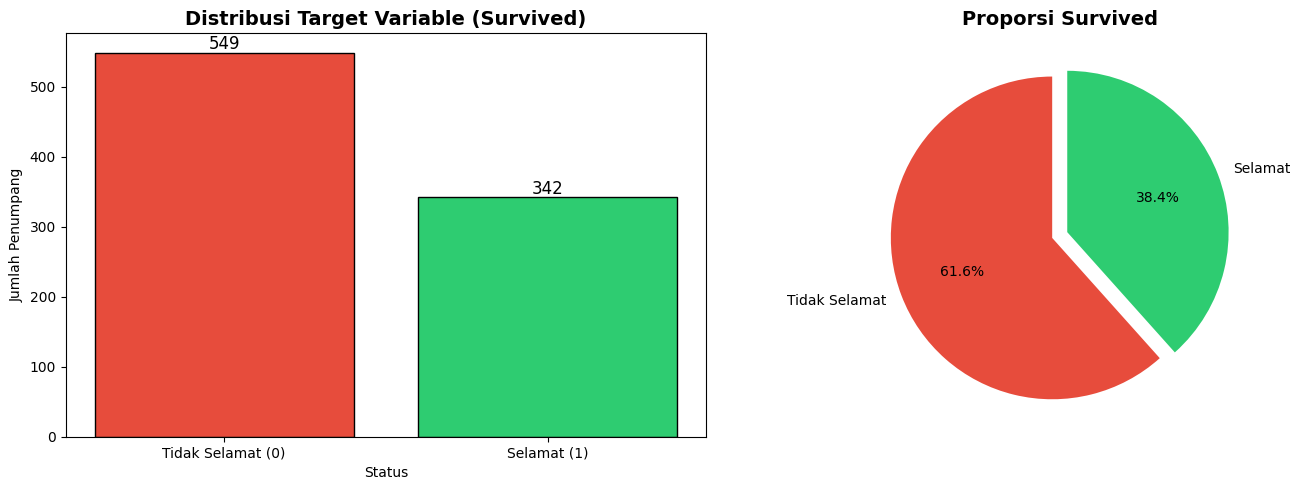

Survival Rate: 38.4%


In [6]:
# 4.2 Distribusi Target Variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
survival_counts = df['Survived'].value_counts()
axes[0].bar(['Tidak Selamat (0)', 'Selamat (1)'], survival_counts.values, 
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribusi Target Variable (Survived)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Penumpang')
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=12)

# Pie chart
axes[1].pie(survival_counts.values, labels=['Tidak Selamat', 'Selamat'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Proporsi Survived', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_survived_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Survival Rate: {df["Survived"].mean()*100:.1f}%')

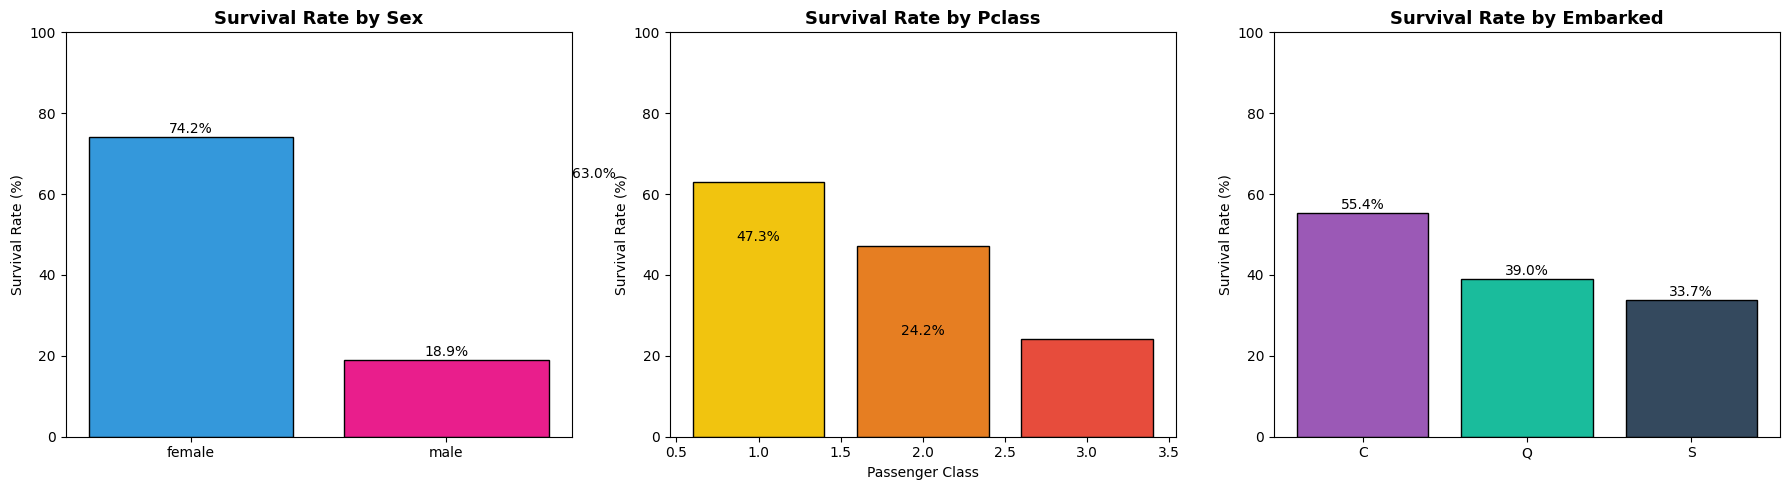

In [7]:
# 4.3 Analisis Fitur Kategorikal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sex vs Survived
sex_survival = df.groupby('Sex')['Survived'].mean() * 100
axes[0].bar(sex_survival.index, sex_survival.values, color=['#3498db', '#e91e8c'], edgecolor='black')
axes[0].set_title('Survival Rate by Sex', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(sex_survival.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center')

# Pclass vs Survived
pclass_survival = df.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(pclass_survival.index, pclass_survival.values, 
            color=['#f1c40f', '#e67e22', '#e74c3c'], edgecolor='black')
axes[1].set_title('Survival Rate by Pclass', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylim(0, 100)
for i, v in zip(pclass_survival.index, pclass_survival.values):
    axes[1].text(i-1, v + 1, f'{v:.1f}%', ha='center')

# Embarked vs Survived
embarked_survival = df.groupby('Embarked')['Survived'].mean() * 100
axes[2].bar(embarked_survival.index, embarked_survival.values, 
            color=['#9b59b6', '#1abc9c', '#34495e'], edgecolor='black')
axes[2].set_title('Survival Rate by Embarked', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Survival Rate (%)')
axes[2].set_ylim(0, 100)
for i, (k, v) in enumerate(embarked_survival.items()):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.savefig('eda_categorical_features.png', dpi=100, bbox_inches='tight')
plt.show()

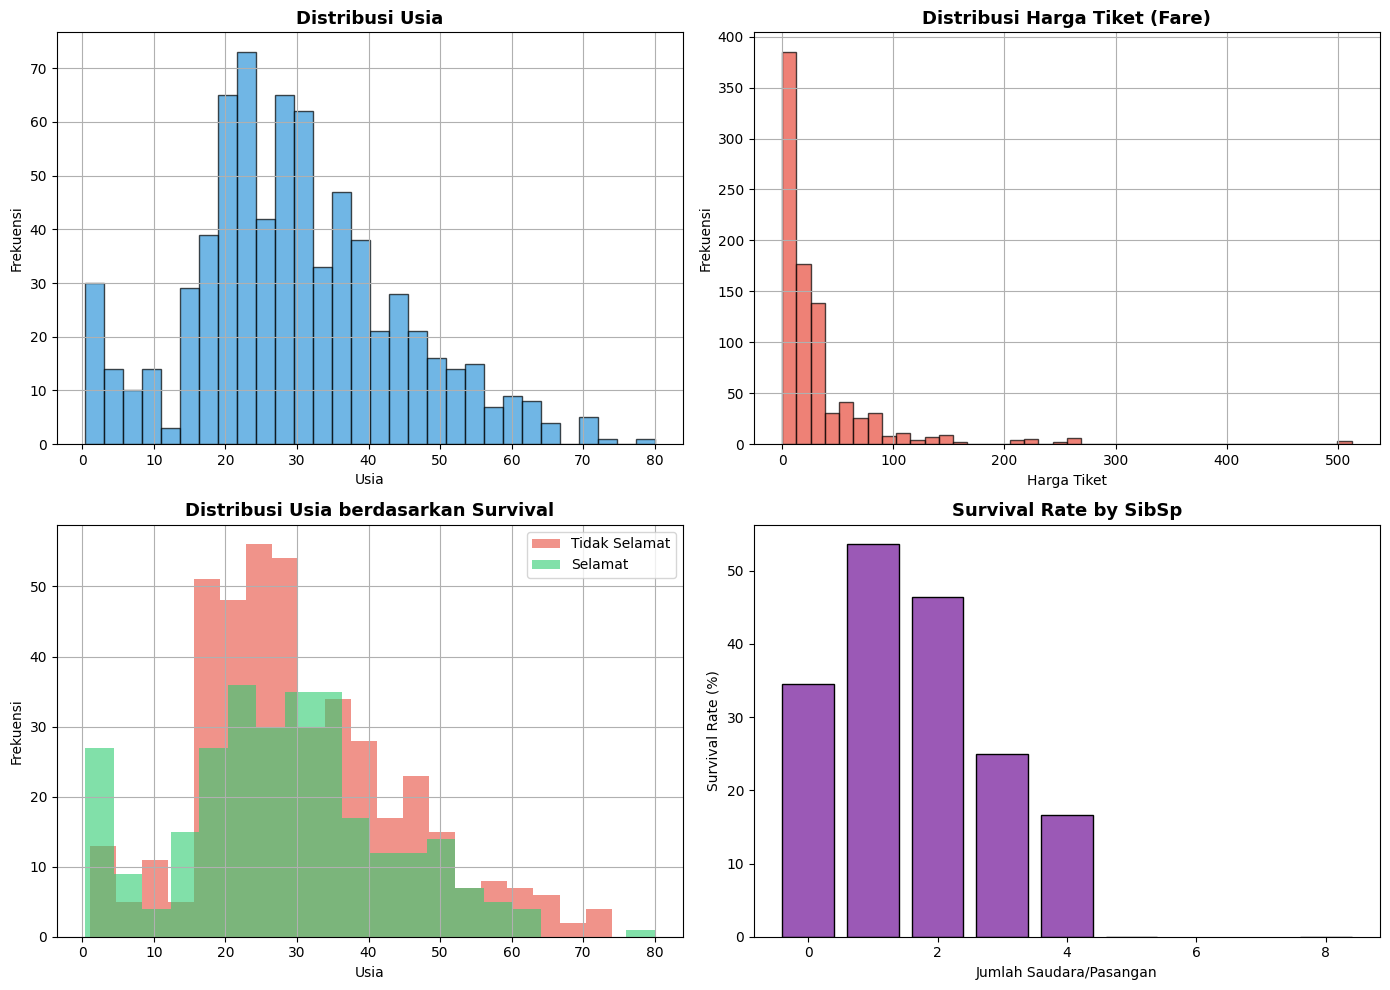

In [8]:
# 4.4 Distribusi Fitur Numerik
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
df['Age'].dropna().hist(bins=30, ax=axes[0,0], color='#3498db', edgecolor='black', alpha=0.7)
axes[0,0].set_title('Distribusi Usia', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Usia')
axes[0,0].set_ylabel('Frekuensi')

# Fare distribution
df['Fare'].hist(bins=40, ax=axes[0,1], color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0,1].set_title('Distribusi Harga Tiket (Fare)', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Harga Tiket')
axes[0,1].set_ylabel('Frekuensi')

# Age by Survived
df[df['Survived']==0]['Age'].dropna().hist(bins=20, ax=axes[1,0], alpha=0.6, color='#e74c3c', label='Tidak Selamat')
df[df['Survived']==1]['Age'].dropna().hist(bins=20, ax=axes[1,0], alpha=0.6, color='#2ecc71', label='Selamat')
axes[1,0].set_title('Distribusi Usia berdasarkan Survival', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Usia')
axes[1,0].set_ylabel('Frekuensi')
axes[1,0].legend()

# SibSp vs Survived
sibsp_survival = df.groupby('SibSp')['Survived'].mean() * 100
axes[1,1].bar(sibsp_survival.index, sibsp_survival.values, color='#9b59b6', edgecolor='black')
axes[1,1].set_title('Survival Rate by SibSp', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Jumlah Saudara/Pasangan')
axes[1,1].set_ylabel('Survival Rate (%)')

plt.tight_layout()
plt.savefig('eda_numerical_features.png', dpi=100, bbox_inches='tight')
plt.show()

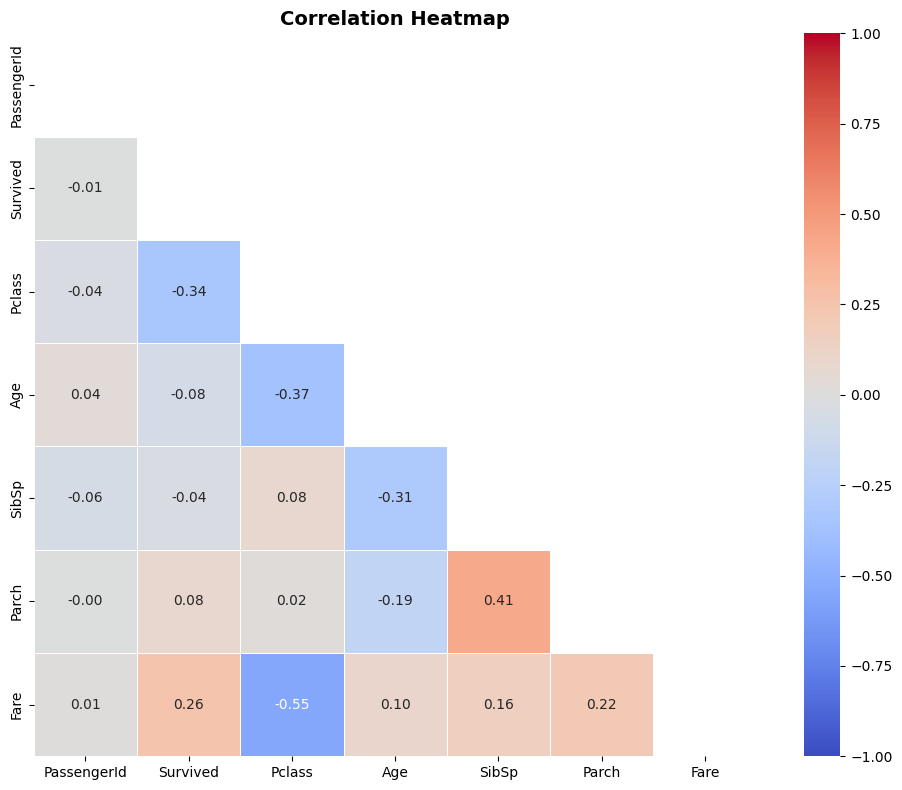

In [9]:
# 4.5 Correlation Heatmap
plt.figure(figsize=(10, 8))
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

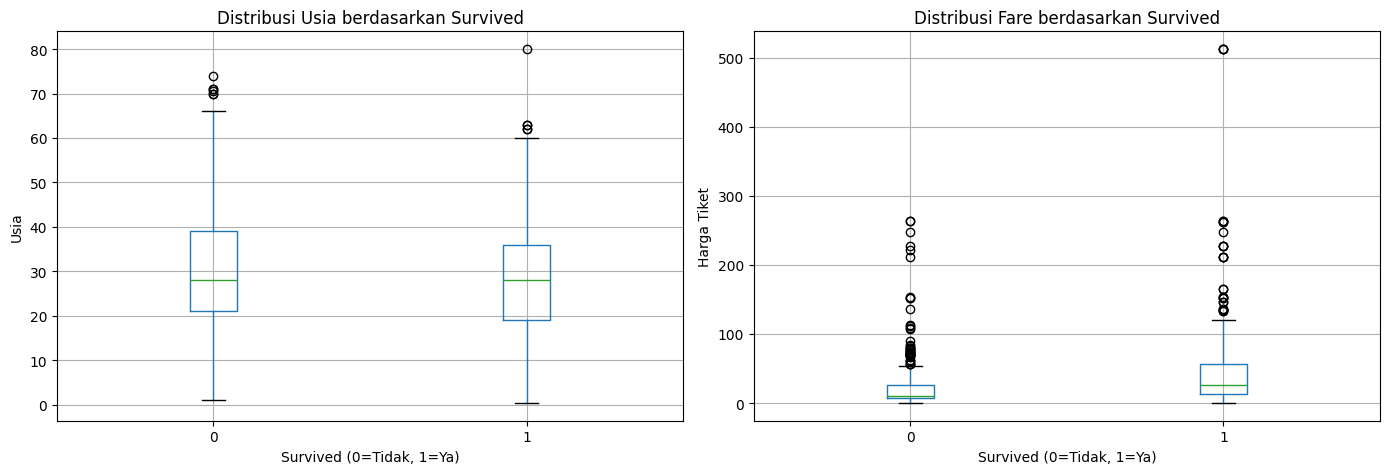

Age: 11 outlier terdeteksi
Fare: 116 outlier terdeteksi


In [10]:
# 4.6 Outlier Detection menggunakan Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Age', by='Survived', ax=axes[0])
axes[0].set_title('Distribusi Usia berdasarkan Survived')
axes[0].set_xlabel('Survived (0=Tidak, 1=Ya)')
axes[0].set_ylabel('Usia')

df.boxplot(column='Fare', by='Survived', ax=axes[1])
axes[1].set_title('Distribusi Fare berdasarkan Survived')
axes[1].set_xlabel('Survived (0=Tidak, 1=Ya)')
axes[1].set_ylabel('Harga Tiket')

plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_boxplot_outliers.png', dpi=100, bbox_inches='tight')
plt.show()

# IQR-based outlier count
for col in ['Age', 'Fare']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    print(f'{col}: {len(outliers)} outlier terdeteksi')

# **5. Data Preprocessing**

Pada tahap ini, dilakukan preprocessing data untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Tahapan preprocessing yang dilakukan:

1. Menghapus Kolom yang Tidak Relevan
2. Menangani Missing Values
3. Feature Engineering (membuat fitur baru)
4. Encoding Data Kategorikal
5. Normalisasi Fitur Numerik
6. Deteksi dan Penanganan Outlier

In [11]:
# 5.1 Drop Kolom Tidak Relevan
df_processed = df.copy()
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_processed = df_processed.drop(columns=cols_to_drop)
print('Kolom setelah drop:', df_processed.columns.tolist())
print(f'Shape setelah drop: {df_processed.shape}')

Kolom setelah drop: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Shape setelah drop: (891, 8)


In [12]:
# 5.2 Feature Engineering - Membuat Fitur Baru
# Fitur FamilySize
df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1

# Fitur IsAlone
df_processed['IsAlone'] = (df_processed['FamilySize'] == 1).astype(int)

# Fitur AgeGroup (Binning)
df_processed['AgeGroup'] = pd.cut(df_processed['Age'],
                                    bins=[0, 12, 18, 35, 60, 100],
                                    labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior'])

# Fitur FareBin (Binning)
df_processed['FareBin'] = pd.qcut(df_processed['Fare'], q=4,
                                    labels=['Low', 'Medium', 'High', 'Very High'])

print('Fitur baru berhasil dibuat!')
print(df_processed[['FamilySize', 'IsAlone', 'AgeGroup', 'FareBin']].head(10))

Fitur baru berhasil dibuat!
   FamilySize  IsAlone     AgeGroup    FareBin
0           2        0  Young Adult        Low
1           2        0        Adult  Very High
2           1        1  Young Adult     Medium
3           2        0  Young Adult  Very High
4           1        1  Young Adult     Medium
5           1        1          NaN     Medium
6           1        1        Adult  Very High
7           5        0        Child       High
8           3        0  Young Adult     Medium
9           2        0     Teenager       High


In [13]:
# 5.3 Menangani Missing Values
print('Missing values sebelum handling:')
print(df_processed.isnull().sum()[df_processed.isnull().sum() > 0])

# Imputasi Age dengan median
median_age = df_processed['Age'].median()
df_processed['Age'].fillna(median_age, inplace=True)

# Imputasi Embarked dengan modus
mode_embarked = df_processed['Embarked'].mode()[0]
df_processed['Embarked'].fillna(mode_embarked, inplace=True)

# Update AgeGroup setelah imputasi Age
df_processed['AgeGroup'] = pd.cut(df_processed['Age'],
                                    bins=[0, 12, 18, 35, 60, 100],
                                    labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior'])

print('\nMissing values setelah handling:')
print(df_processed.isnull().sum())

Missing values sebelum handling:
Age         177
Embarked      2
AgeGroup    177
dtype: int64

Missing values setelah handling:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
AgeGroup      0
FareBin       0
dtype: int64


In [14]:
# 5.4 Penanganan Outlier pada Fare menggunakan Capping (IQR Method)
Q1 = df_processed['Fare'].quantile(0.25)
Q3 = df_processed['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Fare - Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}')
print(f'Outlier sebelum capping: {((df_processed["Fare"] < lower_bound) | (df_processed["Fare"] > upper_bound)).sum()}')

df_processed['Fare'] = df_processed['Fare'].clip(lower=lower_bound, upper=upper_bound)
print(f'Outlier setelah capping: {((df_processed["Fare"] < lower_bound) | (df_processed["Fare"] > upper_bound)).sum()}')

Fare - Lower bound: -26.72, Upper bound: 65.63
Outlier sebelum capping: 116
Outlier setelah capping: 0


In [15]:
# 5.5 Encoding Data Kategorikal
# Label Encoding untuk Sex
le = LabelEncoder()
df_processed['Sex'] = le.fit_transform(df_processed['Sex'])
print('Sex encoding: female=0, male=1')

# Label Encoding untuk Embarked
df_processed['Embarked'] = le.fit_transform(df_processed['Embarked'])
print('Embarked encoding:', {k: v for k, v in zip(['C','Q','S'], range(3))})

# Label Encoding untuk AgeGroup
df_processed['AgeGroup'] = le.fit_transform(df_processed['AgeGroup'].astype(str))

# Label Encoding untuk FareBin
df_processed['FareBin'] = le.fit_transform(df_processed['FareBin'].astype(str))

print('\nDataset setelah encoding:')
df_processed.dtypes

Sex encoding: female=0, male=1
Embarked encoding: {'C': 0, 'Q': 1, 'S': 2}

Dataset setelah encoding:


Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked        int64
FamilySize      int64
IsAlone         int64
AgeGroup        int64
FareBin         int64
dtype: object

In [16]:
# 5.6 Normalisasi Fitur Numerik
scaler = StandardScaler()
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']

df_processed[numerical_cols] = scaler.fit_transform(df_processed[numerical_cols])

print('Statistik setelah normalisasi:')
print(df_processed[numerical_cols].describe().round(4))

Statistik setelah normalisasi:
            Age      Fare     SibSp     Parch  FamilySize
count  891.0000  891.0000  891.0000  891.0000    891.0000
mean     0.0000    0.0000    0.0000    0.0000     -0.0000
std      1.0006    1.0006    1.0006    1.0006      1.0006
min     -2.2242   -1.1747   -0.4745   -0.4737     -0.5610
25%     -0.5657   -0.7883   -0.4745   -0.4737     -0.5610
50%     -0.1046   -0.4686   -0.4745   -0.4737     -0.5610
75%      0.4333    0.3397    0.4328   -0.4737      0.0592
max      3.8916    2.0316    6.7842    6.9741      5.6404


In [17]:
# 5.7 Cek Missing Values Final & Simpan Dataset
print('=== Final Check ===')
print(f'Shape: {df_processed.shape}')
print(f'Missing values: {df_processed.isnull().sum().sum()}')
print(f'Duplicate rows: {df_processed.duplicated().sum()}')
print('\nPreview data preprocessed:')
print(df_processed.head())

# Simpan dataset yang sudah diproses
df_processed.to_csv('titanic_preprocessing.csv', index=False)
print('\nDataset preprocessing berhasil disimpan: titanic_preprocessing.csv')

=== Final Check ===
Shape: (891, 12)
Missing values: 0
Duplicate rows: 123

Preview data preprocessed:
   Survived  Pclass  Sex       Age     SibSp     Parch      Fare  Embarked  \
0         0       3    1 -0.565736  0.432793 -0.473674 -0.820552         2   
1         1       1    0  0.663861  0.432793 -0.473674  2.031623         0   
2         1       3    0 -0.258337 -0.474545 -0.473674 -0.787578         2   
3         1       1    0  0.433312  0.432793 -0.473674  1.419297         2   
4         0       3    1  0.433312 -0.474545 -0.473674 -0.781471         2   

   FamilySize  IsAlone  AgeGroup  FareBin  
0    0.059160        0         4        1  
1    0.059160        0         0        3  
2   -0.560975        1         4        2  
3    0.059160        0         4        3  
4   -0.560975        1         4        2  

Dataset preprocessing berhasil disimpan: titanic_preprocessing.csv


In [18]:
# 5.8 Verifikasi Data Siap Training
X = df_processed.drop('Survived', axis=1)
y = df_processed['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('=== Data Siap untuk Training ===')
print(f'Total fitur: {X.shape[1]}')
print(f'Fitur: {X.columns.tolist()}')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train distribution:\n{y_train.value_counts()}')
print(f'y_test distribution:\n{y_test.value_counts()}')

=== Data Siap untuk Training ===
Total fitur: 11
Fitur: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareBin']
X_train shape: (712, 11)
X_test shape: (179, 11)
y_train distribution:
Survived
0    439
1    273
Name: count, dtype: int64
y_test distribution:
Survived
0    110
1     69
Name: count, dtype: int64
